# Predictive analysis: does rhetoric add information about next-year conflict?

**Predictive question (SDG 16, theme "Restoring trust, managing transformation").**
Do speech-derived theme scores (trust/cooperation and military threat) improve out-of-sample
prediction of next-year armed conflict beyond current conflict, recent conflict history and
military spending, and does any added value extend to countries that are currently at peace?

**Inputs** (produced by the earlier steps, see README): `outputs/prepared.parquet`,
`outputs/ucdp_country_year.parquet` and the shared score cache `outputs/rhetoric_full.sqlite`.
The functions used here live in `analysis_prediction.py`; `scripts/run_prediction.py` runs the
same analysis from the command line. Findings and limitations: `PREDICTION_RESULTS.md`.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import analysis_prediction as ap

pd.set_option("display.precision", 3)

## 1. Modelling table

One row per main-population country-year, speech years 1990–2024, with a known outcome in t+1.

| Role | Columns |
|---|---|
| Target | `conflict_active_t1`: any government-side UCDP conflict in year t+1 |
| Conflict now | `conflict_active_t`, `any_war_t`, `n_conflicts_t` |
| Conflict history | `conflict_years_past5`: UCDP conflict years in t−5 … t−1 (built here) |
| Spending | `log_milex` = log(1 + military spending in % of GDP); missing stays missing |
| Rhetoric | `trust_score`, `threat_score` (full-speech zero-shot scores) |
| Controls | `year`, `log_words` (log speech length), `speaker_post_group` |

In [2]:
prepared, scores, ucdp = ap.load_inputs()
data = ap.build_modelling_table(prepared, scores, ucdp)

print(f"{len(data)} country-years | {data['entity_id'].nunique()} countries | "
      f"{data['milex_share_gdp_t'].notna().sum()} with observed spending | "
      f"conflict next year: {data['conflict_active_t1'].mean():.1%}")
pd.crosstab(data["conflict_active_t"], data["conflict_active_t1"],
            rownames=["conflict in t"], colnames=["conflict in t+1"])

6445 country-years | 193 countries | 5071 with observed spending | conflict next year: 16.5%


conflict in t+1,0,1
conflict in t,,
0.0,5224,159
1.0,159,903


Conflict is highly persistent: 903 of the 1,062 next-year conflicts are continuations, and
only 159 of 5,383 peaceful country-years turn into conflict (onsets).

**Sanity check of the history feature** on a known case (Ukraine, conflict from 2014):

In [3]:
cols = ["year", "conflict_active_t", "conflict_years_past5", "conflict_active_t1"]
data.loc[(data["entity_id"] == "UKR") & data["year"].between(2012, 2017), cols]

,year,conflict_active_t,conflict_years_past5,conflict_active_t1
4143,2012,0.0,0,0
4333,2013,0.0,0,1
4524,2014,1.0,0,1
4715,2015,1.0,1,1
4905,2016,1.0,2,1
5098,2017,1.0,3,1


Why history matters: among countries at peace in year t, the chance of conflict next year rises
steeply with the number of recent conflict years (recurrence).

In [4]:
peaceful = data[data["conflict_active_t"] == 0]
peaceful.groupby("conflict_years_past5")["conflict_active_t1"].agg(["mean", "size"]).rename(
    columns={"mean": "share with conflict in t+1", "size": "rows"})

,share with conflict in t+1,rows
conflict_years_past5,,
0,0.015,4804
1,0.068,263
2,0.159,126
3,0.215,79
4,0.200,65
5,0.370,46


## 2. Models and evaluation design

| Model | Features |
|---|---|
| Persistence (baseline) | predict next year = this year (`conflict_active_t`) |
| History | conflict now + history + controls |
| History + spending | … + `log_milex` |
| History + rhetoric / + spending + rhetoric | … + `trust_score`, `threat_score` |

- **Logistic regression** (scikit-learn), standardised numeric features and one-hot speaker post,
  L2 penalty with fixed `C = 1` and no class reweighting (fixed in advance, not tuned).
  Scaling and encoding are fitted on training rows only.
- **Two comparisons on identical rows:** all countries (no spending) and countries with
  observed spending (5,071 rows). Missing spending is never set to zero.
- **Chronological validation:** train on 1990–2004/2008/2012/2016, validate on the next four
  speech years. The years 2021–2024 are held out and evaluated once at the end.
- **Metrics:** average precision (AP, primary: suited to a rare outcome; "no information"
  equals the share of positives) and ROC-AUC. Each model is graded on all rows and on rows at
  peace in year t (onset prediction, the blind spot of persistence).

## 3. Validation rounds (2005–2020)

In [5]:
rounds = ap.run_validation_rounds(data)

print("Average precision, all rows")
display(ap.summary_table(rounds, "AP_all"))
print("Average precision, rows at peace in year t (onsets)")
display(ap.summary_table(rounds, "AP_peaceful"))

Average precision, all rows


test_years                                                  2005-2008  \
sample                       model                                      
all countries                persistence                        0.748   
                             history                            0.896   
                             history + rhetoric                 0.897   
countries with spending data persistence                        0.769   
                             history                            0.906   
                             history + spending                 0.904   
                             history + spending + rhetoric      0.904   

test_years                                                  2009-2012  \
sample                       model                                      
all countries                persistence                        0.735   
                             history                            0.878   
                             history + rhetoric                 0.880   
countries with spending data persistence                        0.729   
                             history                            0.872   
                             history + spending                 0.872   
                             history + spending + rhetoric      0.873   

test_years                                                  2013-2016  \
sample                       model                                      
all countries                persistence                        0.756   
                             history                            0.893   
                             history + rhetoric                 0.890   
countries with spending data persistence                        0.755   
                             history                            0.889   
                             history + spending                 0.890   
                             history + spending + rhetoric      0.889   

test_years                                                  2017-2020   mean  
sample                       model                                            
all countries                persistence                        0.794  0.758  
                             history                            0.923  0.897  
                             history + rhetoric                 0.922  0.897  
countries with spending data persistence                        0.787  0.760  
                             history                            0.920  0.897  
                             history + spending                 0.918  0.896  
                             history + spending + rhetoric      0.920  0.896

Average precision, rows at peace in year t (onsets)


test_years                                                  2005-2008  \
sample                       model                                      
all countries                persistence                        0.026   
                             history                            0.222   
                             history + rhetoric                 0.235   
countries with spending data persistence                        0.028   
                             history                            0.252   
                             history + spending                 0.246   
                             history + spending + rhetoric      0.239   

test_years                                                  2009-2012  \
sample                       model                                      
all countries                persistence                        0.024   
                             history                            0.075   
                             history + rhetoric                 0.085   
countries with spending data persistence                        0.030   
                             history                            0.105   
                             history + spending                 0.105   
                             history + spending + rhetoric      0.121   

test_years                                                  2013-2016  \
sample                       model                                      
all countries                persistence                        0.036   
                             history                            0.341   
                             history + rhetoric                 0.322   
countries with spending data persistence                        0.042   
                             history                            0.376   
                             history + spending                 0.384   
                             history + spending + rhetoric      0.379   

test_years                                                  2017-2020   mean  
sample                       model                                            
all countries                persistence                        0.027  0.029  
                             history                            0.364  0.251  
                             history + rhetoric                 0.340  0.246  
countries with spending data persistence                        0.035  0.034  
                             history                            0.375  0.277  
                             history + spending                 0.380  0.279  
                             history + spending + rhetoric      0.345  0.271

In [6]:
# Number of conflicts and onsets per validation period (all-countries sample)
(rounds[(rounds["sample"] == "all countries") & (rounds["model"] == "persistence")]
 [["test_years", "n_rows", "n_conflicts", "n_onsets"]].reset_index(drop=True))

,test_years,n_rows,n_conflicts,n_onsets
0,2005-2008,752,106,17
1,2009-2012,761,106,16
2,2013-2016,762,135,23
3,2017-2020,768,140,17


**Reading.** History beats persistence in every period (mean AP about 0.90 vs 0.76). Adding
rhetoric changes overall AP by at most ±0.003. For onsets, rhetoric is slightly higher in
2005–2012 and slightly lower in 2013–2020; with only 16–23 onsets per period there is no
consistent gain. Spending shows the same pattern.

## 4. Final evaluation on held-out years 2021–2024 (trained through 2020, run once)

In [7]:
final, final_models = ap.run_final_evaluation(data)
final[["sample", "model", "n_rows", "n_conflicts", "n_onsets",
       "AP_all", "ROC_AUC_all", "AP_peaceful"]]

,sample,model,n_rows,n_conflicts,n_onsets,AP_all,ROC_AUC_all,AP_peaceful
0,all countries,persistence,759,137,12,0.867,0.949,0.019
1,all countries,history,759,137,12,0.949,0.968,0.213
2,all countries,history + rhetoric,759,137,12,0.950,0.969,0.228
3,countries with spending data,persistence,602,126,12,0.858,0.943,0.025
4,countries with spending data,history,602,126,12,0.944,0.963,0.183
5,countries with spending data,history + spending,602,126,12,0.945,0.964,0.225
6,countries with spending data,history + spending + rhetoric,602,126,12,0.945,0.965,0.234


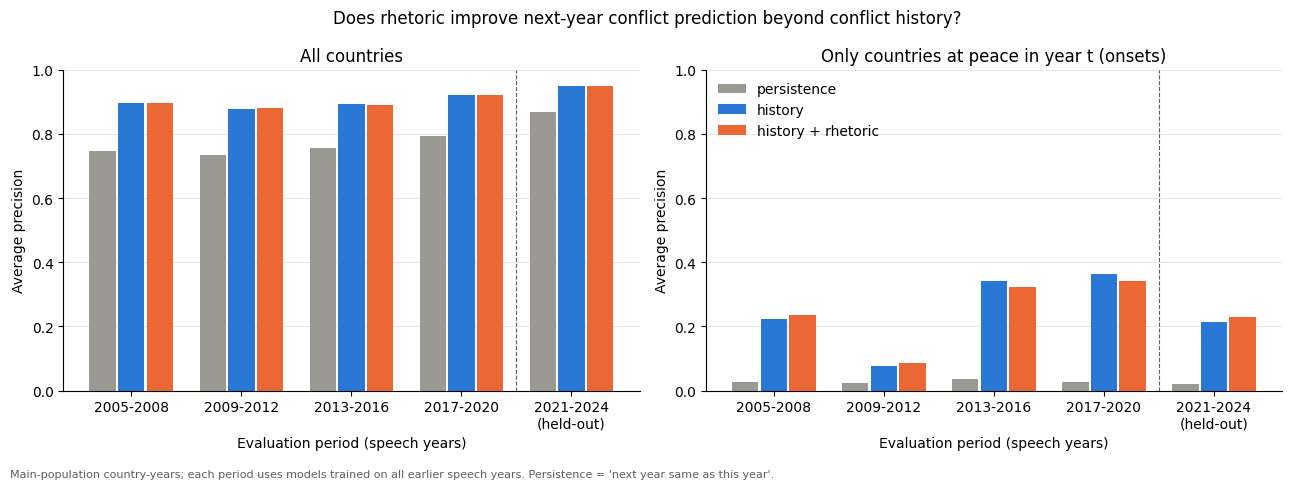

In [8]:
fig = ap.plot_rounds(rounds, final)

**Reading.** The held-out years confirm the ranking: history (AP 0.95) clearly beats
persistence (0.87); rhetoric adds 0.001 overall. Onset AP rises from 0.213 to 0.228 with
rhetoric, but this rests on only 12 onsets and the same comparison went both ways in the
validation rounds, so it is not evidence of a reliable gain. Scores are higher in 2021–2024
for all models (including persistence) because that period had relatively few onsets; compare
models within a period, not across periods.

## 5. Coefficients of the final models

Coefficients are on standardised features: the change in log-odds of conflict in t+1 per one
standard deviation increase, holding the other features constant. `exp(coefficient)` is the
odds ratio. Regularisation (C = 1) shrinks coefficients slightly; scikit-learn reports no
standard errors, so these describe direction and relative size of associations, not
significance or causation.

In [9]:
coefficients = ap.coefficient_table(final_models)
main_rows = ap.HISTORY + ap.SPENDING + ap.RHETORIC + ap.CONTROLS
print("Coefficients (standardised)")
display(coefficients.loc[main_rows])
print("Odds ratios per one standard deviation")
display(np.exp(coefficients.loc[main_rows]))

Coefficients (standardised)


,all countries: history,all countries: history + rhetoric,countries with spending data: history,countries with spending data: history + spending,countries with spending data: history + spending + rhetoric
conflict_active_t,0.831,0.824,0.853,0.846,0.834
any_war_t,0.243,0.228,0.229,0.220,0.209
n_conflicts_t,0.619,0.617,0.677,0.678,0.690
conflict_years_past5,0.928,0.925,0.994,0.983,0.986
log_milex,NaN,NaN,NaN,0.081,0.050
trust_score,NaN,-0.142,NaN,NaN,-0.173
threat_score,NaN,0.112,NaN,NaN,0.067
year,0.187,0.177,0.196,0.203,0.181
log_words,0.117,0.086,0.079,0.075,0.047


Odds ratios per one standard deviation


,all countries: history,all countries: history + rhetoric,countries with spending data: history,countries with spending data: history + spending,countries with spending data: history + spending + rhetoric
conflict_active_t,2.296,2.279,2.346,2.331,2.303
any_war_t,1.276,1.256,1.257,1.246,1.233
n_conflicts_t,1.857,1.854,1.967,1.970,1.994
conflict_years_past5,2.529,2.521,2.702,2.672,2.680
log_milex,NaN,NaN,NaN,1.084,1.051
trust_score,NaN,0.867,NaN,NaN,0.841
threat_score,NaN,1.118,NaN,NaN,1.070
year,1.206,1.194,1.216,1.225,1.198
log_words,1.124,1.090,1.083,1.078,1.048


**Reading.** History dominates (odds ratio about 2.5 per SD of `conflict_years_past5`, 2.3 for
current conflict). Rhetoric has the hypothesised signs, with more cooperation language
associated with lower risk (OR about 0.87 per SD) and more threat language with higher risk
(OR about 1.12), but its effects are several times smaller and barely change the ranking of
countries, which is what AP measures.

## 6. Answer to the predictive question

Conflict history is by far the strongest predictor of next-year conflict. UN speech rhetoric is
associated with conflict in the expected direction, but adding it does not reliably improve
out-of-sample prediction beyond conflict history and military spending, neither overall nor for
new conflict onsets. See `PREDICTION_RESULTS.md` for limitations and possible extensions.

In [10]:
# Optional: save all tables and the figure (same as scripts/run_prediction.py)
# import subprocess, sys
# subprocess.run([sys.executable, "scripts/run_prediction.py"], check=True)